<a href="https://colab.research.google.com/github/gauravjha201/Brain_Tumor_Adversarial_Robustness/blob/main/Stage_A_baselineModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os


In [23]:
DATASET_PATH='/content/drive/MyDrive/Br35H'
IMG_SIZE=224
BATCH_SIZE=32

In [24]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 3023 files belonging to 2 classes.
Using 2419 files for training.
Found 3023 files belonging to 2 classes.
Using 604 files for validation.


In [25]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset=train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset =val_dataset.map(lambda x, y: (normalization_layer(x), y))

In [26]:
AUTOTUNE=tf.data.AUTOTUNE

train_dataset=train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset=val_dataset.prefetch(buffer_size=AUTOTUNE)


In [27]:
base_model=tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable=False


In [28]:
model=tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
history=model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
    )

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8871 - loss: 0.2623 - val_accuracy: 0.9570 - val_loss: 0.1309
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9512 - loss: 0.1276 - val_accuracy: 0.9669 - val_loss: 0.1058
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9669 - loss: 0.0870 - val_accuracy: 0.9719 - val_loss: 0.0973
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9773 - loss: 0.0642 - val_accuracy: 0.9801 - val_loss: 0.0683
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9847 - loss: 0.0493 - val_accuracy: 0.9834 - val_loss: 0.0651


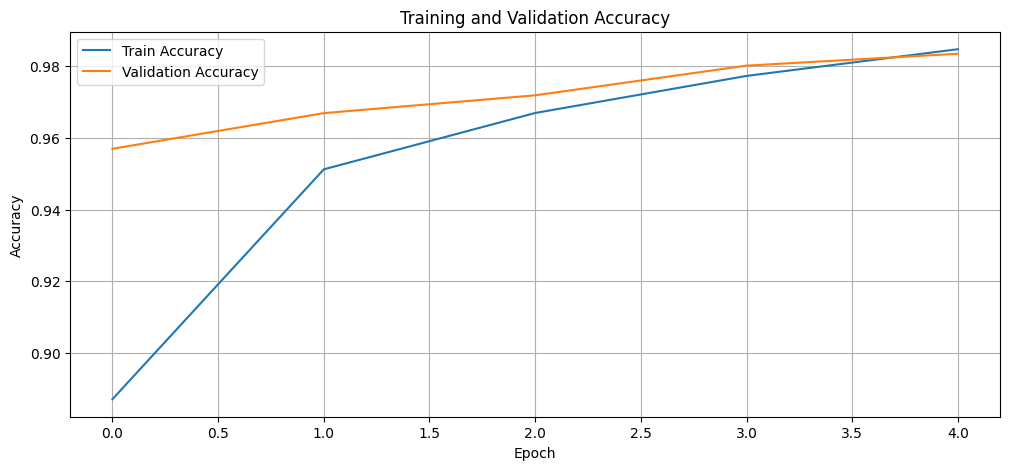

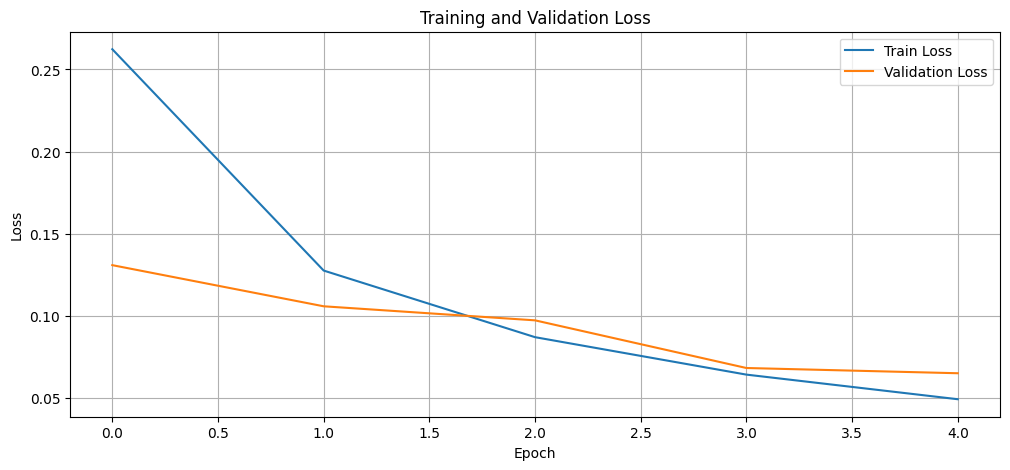

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [32]:
baseline_acc=model.evaluate(val_dataset)
print("Baseline Model Accuracy :",baseline_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9834 - loss: 0.0651
Baseline Model Accuracy : [0.06508443504571915, 0.9834437370300293]


In [33]:
temp_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)
print(temp_dataset.class_names)

Found 3023 files belonging to 2 classes.
Using 2419 files for training.
['no', 'yes']


In [37]:
if baseline_acc[1]>0.8:
  model.save('/content/drive/MyDrive/baseline_model.h5')
  print(" Model saved!")

else:
  print(f" Accuracy {baseline_acc[1]:.4f} below threshold. Model not saved.")

 Model saved!
